## eval
calculate the scores


In [6]:
import nltk
nltk.download('cmudict')
nltk.download('punkt_tab')

[nltk_data] Downloading package cmudict to /home/yc/nltk_data...
[nltk_data]   Package cmudict is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/yc/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import re
from nltk.corpus import cmudict
from nltk.tokenize import sent_tokenize, word_tokenize


Flesch Reading Ease Score: 76.97


In [ ]:
# Load CMU Pronouncing Dictionary for syllable counting
d = cmudict.dict()

def count_syllables(word):
    """Count the syllables in a word using the CMU Pronouncing Dictionary."""
    if word.lower() in d:
        return max([len([s for s in pron if s[-1].isdigit()]) for pron in d[word.lower()]])
    else:
        # Estimate syllables for unknown words
        return len(re.findall(r'[aeiouy]+', word.lower()))

def flesch_reading_ease(text):
    """Calculate the Flesch Reading Ease Score for the given text."""
    sentences = sent_tokenize(text)
    words = word_tokenize(text)
    num_sentences = len(sentences)
    num_words = len(words)
    num_syllables = sum(count_syllables(word) for word in words)
    
    # Avoid division by zero
    if num_sentences == 0 or num_words == 0:
        return 0

    # Apply the FRES formula
    fres = 206.835 - 1.015 * (num_words / num_sentences) - 84.6 * (num_syllables / num_words)
    return fres

# Example usage
text = """
The quick brown fox jumps over the lazy dog. This is a simple sentence to demonstrate readability.
"""
print(f"Flesch Reading Ease Score: {flesch_reading_ease(text):.2f}")


In [45]:
with open('out.txt', "r", encoding="utf-8") as file:
    text = file.read()
res=text.split('\n')
res=[a.split('"')[1] for a in res] 
res=[a.split(' [/INST]  ') for a in res]  # remove prompt
res=[a[1]  for a in res if len(a)==2] # remove bad outputs (out of token limit)

def trim(s):
    # trim the sentence to the last peroid.
    ls=s.split('.')
    s='.'. join(ls[:-1])+'.'
    return s
def humanreadable(s):
    # replace the break line to space.
    return s.replace('\\n',' ')

res=[trim(a) for a in res]
res=[humanreadable(a) for a in res]

res[:2]


['A period of time during pregnancy. Also called term pregnancy. A pregnancy that lasts 37 to 42 weeks (280 days) after the first day of the last menstrual period. Also called full-term pregnancy. A term that is used to describe the length of a pregnancy. Term can also be used to describe the end of a pregnancy. For example, a full-term pregnancy is one that lasts 37 to 42 weeks (280 days) after the first day of the last menstrual period. Term can also be used to describe the end of a pregnancy. For example, a full-term pregnancy is one that lasts 37 to 42 weeks (280 days) after the first day of the last menstrual period. Also called term pregnancy.',
 'A test to measure the level of certain substances in the body. A biomarker is a substance that can be used to detect or measure a specific disease or condition. Biomarkers can be used to monitor the progression of a disease or to determine whether treatment is working. A biomarker test can measure the level of a substance in a sample of

In [50]:
# load formal def to compare
import csv
# Path to the CSV file
csv_file_path = 'processeddata.csv'

# Read the CSV into a list of rows
with open(csv_file_path, mode='r', encoding='utf-8') as file:
    reader = csv.reader(file)
    # Convert the reader object to a list (skipping the header row)
    data = [row for row in reader]

# Separate the header and the rows
header = data[0]
rows = data[1:]


formal=[]
easy=[]

for row in rows:
    term, easy_explanation, formal_explanation = row
    formal.append(formal_explanation)
    easy.append(easy_explanation)

In [51]:
fres_model=[]
for a in res:
    fres_model.append(flesch_reading_ease(a))
    
fres_formal=[]
for a in formal:
    fres_formal.append(flesch_reading_ease(a))
fres_easy=[]
for a in easy:
    fres_easy.append(flesch_reading_ease(a))


In [53]:
import numpy as np

def basic_stats(samples):
    """Calculate and print basic statistics of the given samples."""
    # Convert to numpy array for easier manipulation
    samples = np.array(samples)
    
    # Calculate the basic statistics
    mean = np.mean(samples)
    median = np.median(samples)
    std_dev = np.std(samples)
    minimum = np.min(samples)
    maximum = np.max(samples)
    quantiles = np.percentile(samples, [25, 50, 75])
    
    # Print out the statistics
    print(f"Mean: {mean:.2f}")
    print(f"Median: {median:.2f}")
    print(f"Standard Deviation: {std_dev:.2f}")
    print(f"Minimum: {minimum:.2f}")
    print(f"Maximum: {maximum:.2f}")
    print(f"25th Percentile: {quantiles[0]:.2f}")
    print(f"50th Percentile (Median): {quantiles[1]:.2f}")
    print(f"75th Percentile: {quantiles[2]:.2f}")


In [56]:
print('\neasy data')
basic_stats(fres_easy)
print('\nformal data')
basic_stats(fres_formal)
print('\nmodel output')
basic_stats(fres_model)


easy data
Mean: 70.36
Median: 71.32
Standard Deviation: 19.62
Minimum: -78.21
Maximum: 120.55
25th Percentile: 60.02
50th Percentile (Median): 71.32
75th Percentile: 81.31

formal data
Mean: 69.25
Median: 69.72
Standard Deviation: 14.65
Minimum: 3.34
Maximum: 117.16
25th Percentile: 59.76
50th Percentile (Median): 69.72
75th Percentile: 78.29

model output
Mean: 72.60
Median: 72.99
Standard Deviation: 13.27
Minimum: 20.93
Maximum: 104.01
25th Percentile: 64.65
50th Percentile (Median): 72.99
75th Percentile: 81.73


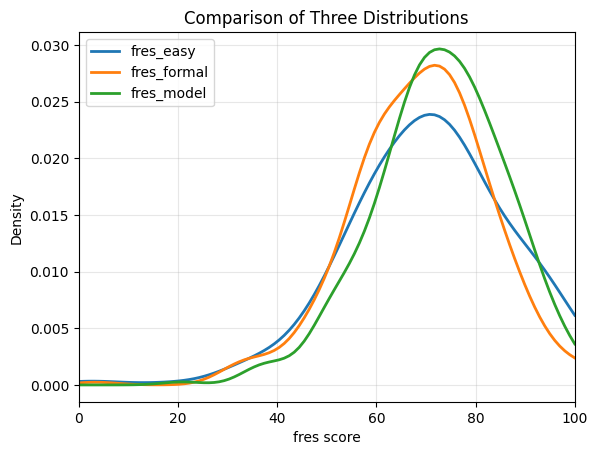

In [68]:
from matplotlib import pyplot as plt
from scipy.stats import gaussian_kde
bins=55
# _=plt.hist(fres_easy, bins=bins, alpha=0.6, label='Distribution 1', density=True)
# _=plt.hist(fres_formal, bins=bins, alpha=0.6, label='Distribution 2', density=True)
# _=plt.hist(fres_model, bins=bins, alpha=0.6, label='Distribution 3', density=True)
# KDE for each dataset
bandwidth=None
x_values=np.linspace(0,100,100)
kde1 = gaussian_kde(fres_easy, bw_method=bandwidth)
kde2 = gaussian_kde(fres_formal, bw_method=bandwidth)
kde3 = gaussian_kde(fres_model, bw_method=bandwidth)

# Plot the KDE curves
plt.plot(x_values, kde1(x_values), label='fres_easy', linewidth=2)
plt.plot(x_values, kde2(x_values), label='fres_formal', linewidth=2)
plt.plot(x_values, kde3(x_values), label='fres_model', linewidth=2)

plt.title("Comparison of Three Distributions")
plt.xlabel("fres score")
plt.ylabel("Density")
plt.legend()

plt.xlim(0,100)
plt.grid(True, alpha=0.3)
plt.show()


In [70]:
from scipy.stats import ttest_ind


# Perform a two-sample t-test
t_stat, p_value = ttest_ind(fres_formal, fres_model)


print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.4f}")

print(f"fres score of formal defination and our model output is different")


T-statistic: -3.27
P-value: 0.0011
fres score of formal defination and our model output is different
